# Índice de Atractividad Regional de España (IAR)

**¿En qué comunidad autónoma debería una empresa abrir su próxima sede u operación?**

Este cuaderno resuelve esa pregunta de negocio de principio a fin con datos
públicos del INE: **lectura → limpieza → cálculo de un índice → visualización →
recomendación**. El objetivo no es programar por programar, sino *estructurar
una decisión* con datos y hacerla transparente y defendible.

**Idea en una frase:** ninguna región gana en todo. Madrid tiene el mercado más
rico pero el coste más alto; el sur es barato pero con más paro. Un índice
compuesto permite comparar "peras con manzanas" y ver quién ofrece el mejor
*equilibrio* según la estrategia de cada empresa.

---
*Autor: Vicente Marco Pastor · Datos: INE (Contabilidad Regional, EPA, ECP, ETCL)*

## 1. Los datos

Cuatro indicadores oficiales del INE, una fila por comunidad autónoma (17 CCAA).
Cada uno representa una **dimensión** de la decisión de localización:

| Indicador | Dimensión de negocio | Fuente INE | ¿Más es mejor? |
|---|---|---|---|
| PIB per cápita 2024 (€) | Riqueza / poder de compra del mercado | Contabilidad Regional | Sí ↑ |
| Tasa de paro 2T 2026 (%) | Salud del mercado laboral | EPA | No ↓ |
| Población 1-ene-2025 (hab.) | Tamaño del mercado | Estad. Continua de Población | Sí ↑ |
| Coste laboral 2024 (€/trab./mes) | Coste de operar | Enc. de Coste Laboral | No ↓ |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/indicadores_ccaa.csv")
df

,comunidad,pib_per_capita_2024,tasa_paro_2t2026,poblacion_2025,coste_laboral_2024
0,Madrid,44755,7.58,7125583,3843.65
1,País Vasco,41016,7.11,2240113,3708.23
2,Navarra,39076,8.07,683525,3565.42
3,Cataluña,37426,7.90,8119550,3483.35
4,Aragón,36446,8.17,1352630,3215.54
5,Illes Balears,36011,6.11,1244394,3314.09
6,La Rioja,34475,8.77,327115,3019.88
7,Castilla y León,31149,8.37,2397889,2981.68
8,Galicia,30105,7.94,2715424,2947.40
9,Cantabria,29791,7.34,593386,3030.77


## 2. Limpieza y control de calidad

Antes de calcular nada, comprobamos que los datos son fiables. Dos chequeos
rápidos: (1) que no falten valores ni haya comunidades duplicadas, y (2) una
**prueba de coherencia**: si nuestra tasa de paro por CCAA es correcta, su
media ponderada por población debe dar aproximadamente la tasa nacional que
publica el INE (**9,87 %** en el 2T 2026).

In [2]:
assert df["comunidad"].is_unique, "Comunidades duplicadas"
assert df.isnull().sum().sum() == 0, "Hay valores vacíos"

paro_nacional = (df["tasa_paro_2t2026"] * df["poblacion_2025"]).sum() / df["poblacion_2025"].sum()
print(f"Paro medio ponderado por población: {paro_nacional:.2f}%")
print("Referencia INE nacional 2T 2026:    9,87%")
print("=> Diferencia mínima (excluimos Ceuta y Melilla): los datos cuadran.")

Paro medio ponderado por población: 9.89%
Referencia INE nacional 2T 2026:    9,87%
=> Diferencia mínima (excluimos Ceuta y Melilla): los datos cuadran.


## 3. Normalización: poner todo en la misma escala (0–100)

**El problema:** no se pueden sumar euros (44.755) con porcentajes (7,58) ni con
habitantes (7 millones). **La solución:** reescalar cada indicador a una nota de
**0 a 100** con el método *min-max* (el peor valor = 0, el mejor = 100).

Para los indicadores donde "menos es mejor" (paro y coste) **invertimos** la
escala, para que 100 signifique siempre "más atractivo".

In [3]:
def normaliza(serie, mas_es_mejor=True):
    """Reescala una serie a 0-100. Si menos es mejor, invierte (100 - x)."""
    base = (serie - serie.min()) / (serie.max() - serie.min()) * 100
    return base if mas_es_mejor else 100 - base

df["s_riqueza"] = normaliza(df["pib_per_capita_2024"], True)   # + mejor
df["s_empleo"]  = normaliza(df["tasa_paro_2t2026"],    False)  # - mejor
df["s_mercado"] = normaliza(df["poblacion_2025"],      True)   # + mejor
df["s_coste"]   = normaliza(df["coste_laboral_2024"],  False)  # - mejor

df[["comunidad", "s_riqueza", "s_empleo", "s_mercado", "s_coste"]].round(1)

,comunidad,s_riqueza,s_empleo,s_mercado,s_coste
0,Madrid,100.0,82.6,81.6,0.0
1,País Vasco,81.5,88.2,22.9,11.8
2,Navarra,71.9,76.8,4.3,24.2
3,Cataluña,63.7,78.8,93.5,31.3
4,Aragón,58.8,75.6,12.3,54.5
5,Illes Balears,56.7,100.0,11.0,46.0
6,La Rioja,49.1,68.5,0.0,71.5
7,Castilla y León,32.6,73.3,24.8,74.9
8,Galicia,27.4,78.3,28.7,77.8
9,Cantabria,25.9,85.4,3.2,70.6


## 4. El índice compuesto y tres escenarios de estrategia

El **Índice de Atractividad Regional (IAR)** es la media *ponderada* de las
cuatro notas. La pregunta clave de consultoría es: **¿qué peso damos a cada
dimensión?** No hay una respuesta única, así que probamos tres estrategias —
esto es un **análisis de sensibilidad** y demuestra la robustez de la conclusión:

- **Equilibrado** — los 4 factores pesan igual (caso base, sin opinión previa).
- **Orientado a mercado** — abrir una sede comercial: prima riqueza y tamaño.
- **Orientado a coste** — un back-office o centro de servicios: prima el coste
  bajo y una bolsa amplia de mano de obra.

In [4]:
DIMS = ["s_riqueza", "s_empleo", "s_mercado", "s_coste"]
escenarios = {
    #                        riqueza empleo mercado coste
    "Equilibrado":          (0.25,  0.25,  0.25,   0.25),
    "Orientado a mercado":  (0.35,  0.15,  0.35,   0.15),
    "Orientado a coste":    (0.15,  0.15,  0.30,   0.40),
}
for nombre, pesos in escenarios.items():
    df[f"IAR_{nombre}"] = sum(p * df[d] for p, d in zip(pesos, DIMS))

ranking = df.sort_values("IAR_Equilibrado", ascending=False).reset_index(drop=True)
ranking.index += 1
ranking[["comunidad", "IAR_Equilibrado",
         "IAR_Orientado a mercado", "IAR_Orientado a coste"]].round(1)

,comunidad,IAR_Equilibrado,IAR_Orientado a mercado,IAR_Orientado a coste
1,Cataluña,66.8,71.5,61.9
2,Madrid,66.0,75.9,51.9
3,Illes Balears,53.4,45.6,45.2
4,Galicia,53.1,43.1,55.6
5,Castilla y León,51.4,42.3,53.3
6,País Vasco,51.1,51.5,37.0
7,Aragón,50.3,44.4,45.7
8,Comunitat Valenciana,49.7,45.1,58.8
9,La Rioja,47.3,38.2,46.3
10,Andalucía,46.8,48.1,64.9


## 5. Visualización

### 5.1 Ranking base (escenario equilibrado)
**Cataluña (66,8) adelanta por poco a Madrid (66,0).** Es el hallazgo
contraintuitivo: Madrid gana en riqueza y casi en mercado, pero su **coste
laboral, el más alto de España, la penaliza** hasta empatar con una Cataluña
que combina mercado grande, paro bajo y coste algo menor.

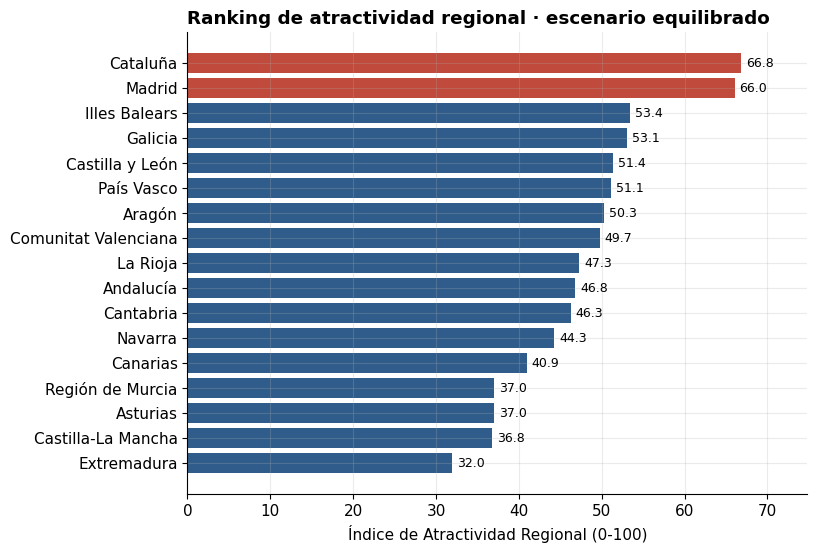

In [5]:
AZUL, GRIS, ROJO = "#2F5C8A", "#B9C2CC", "#C04A3B"
plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

orden = ranking.sort_values("IAR_Equilibrado")
colores = [ROJO if c in tuple(orden["comunidad"].iloc[-2:]) else AZUL for c in orden["comunidad"]]
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(orden["comunidad"], orden["IAR_Equilibrado"], color=colores)
for y, v in enumerate(orden["IAR_Equilibrado"]):
    ax.text(v + 0.6, y, f"{v:.1f}", va="center", fontsize=9)
ax.set_xlabel("Índice de Atractividad Regional (0-100)")
ax.set_title("Ranking de atractividad regional · escenario equilibrado", fontweight="bold", loc="left")
ax.margins(x=0.12)
plt.show()

### 5.2 Perfil por dimensiones
El mapa de calor muestra **por qué** cada región puntúa como puntúa. Se lee de
un vistazo: azul oscuro = fuerte, amarillo = débil. Andalucía es imbatible en
tamaño de mercado y coste, pero se hunde en riqueza y empleo; Madrid es lo
contrario.

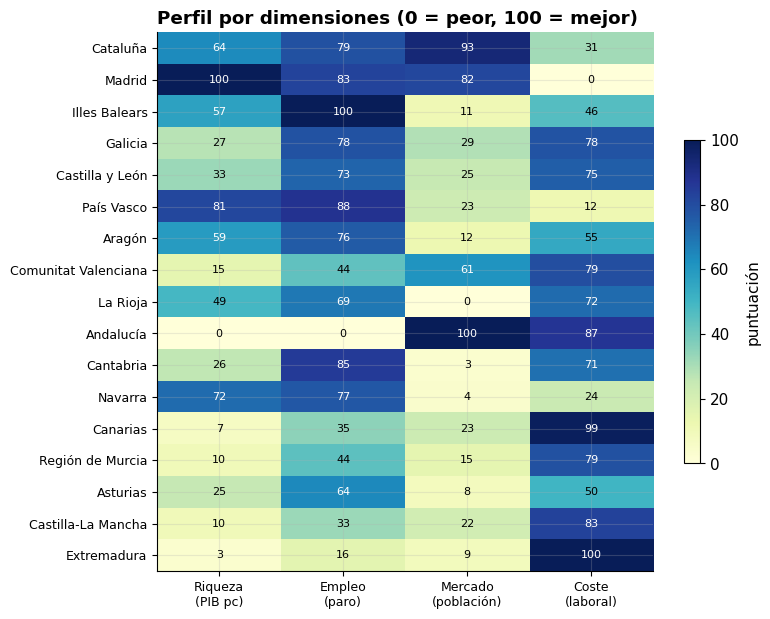

In [6]:
fig, ax = plt.subplots(figsize=(8, 7))
mat = ranking.set_index("comunidad")[DIMS]
etiq = ["Riqueza\n(PIB pc)", "Empleo\n(paro)", "Mercado\n(población)", "Coste\n(laboral)"]
im = ax.imshow(mat.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=100)
ax.set_xticks(range(4)); ax.set_xticklabels(etiq, fontsize=9)
ax.set_yticks(range(len(mat))); ax.set_yticklabels(mat.index, fontsize=9)
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        v = mat.values[i, j]
        ax.text(j, i, f"{v:.0f}", ha="center", va="center",
                color="white" if v > 55 else "black", fontsize=8)
ax.set_title("Perfil por dimensiones (0 = peor, 100 = mejor)", fontweight="bold", loc="left")
fig.colorbar(im, ax=ax, shrink=0.6, label="puntuación")
plt.show()

### 5.3 La tensión clave: mercado frente a coste
Cada burbuja es una comunidad; su **tamaño es la población**. Arriba-izquierda
es el ideal (mercado rico y barato). Madrid está arriba pero muy a la derecha
(caro); **Cataluña es la burbuja grande mejor situada hacia el centro**: mercado
potente sin el sobrecoste de Madrid.

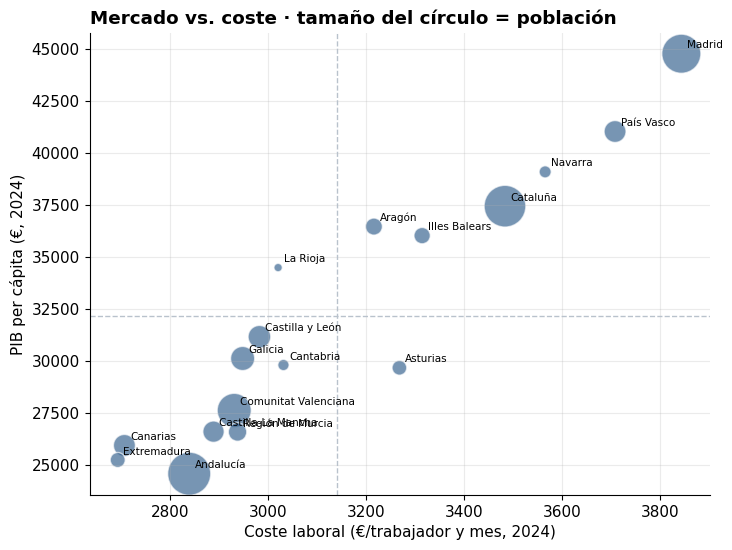

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["coste_laboral_2024"], df["pib_per_capita_2024"],
           s=df["poblacion_2025"]/9000, color=AZUL, alpha=0.65, edgecolor="white")
ax.axhline(df["pib_per_capita_2024"].mean(), color=GRIS, ls="--", lw=1)
ax.axvline(df["coste_laboral_2024"].mean(), color=GRIS, ls="--", lw=1)
for _, r in df.iterrows():
    ax.annotate(r["comunidad"], (r["coste_laboral_2024"], r["pib_per_capita_2024"]),
                fontsize=7.5, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Coste laboral (€/trabajador y mes, 2024)")
ax.set_ylabel("PIB per cápita (€, 2024)")
ax.set_title("Mercado vs. coste · tamaño del círculo = población", fontweight="bold", loc="left")
plt.show()

### 5.4 Análisis de sensibilidad
**El "mejor sitio" depende de la estrategia.** Si prima el mercado, gana Madrid;
si prima el coste, gana Andalucía. Pero **Cataluña es la única que se mantiene
en el Top-2 de los tres escenarios**: la apuesta más robusta ante la
incertidumbre sobre qué priorizar.

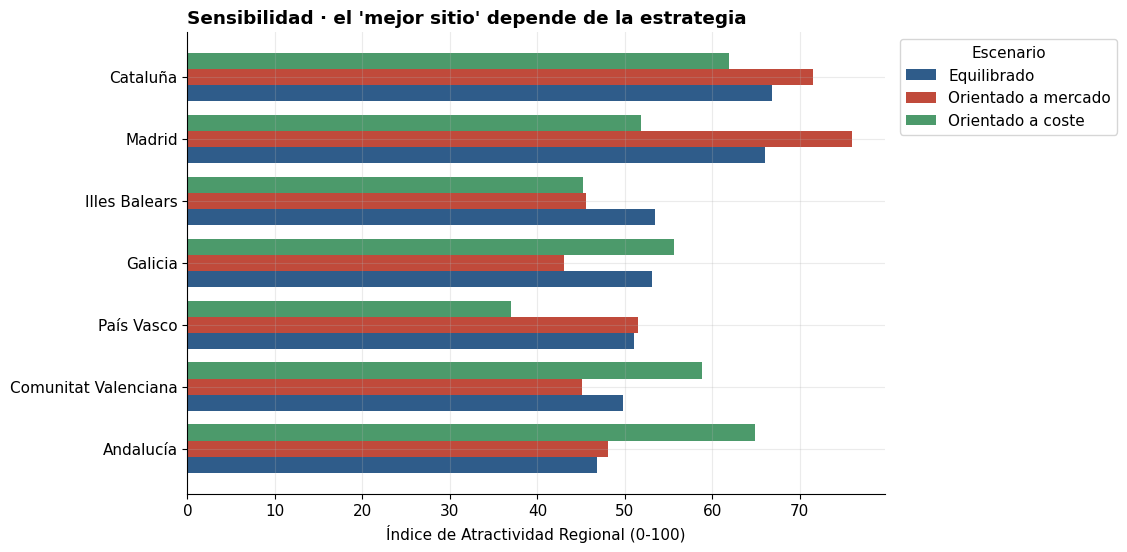

In [8]:
top = set()
for n in escenarios:
    top.update(ranking.nlargest(4, f"IAR_{n}")["comunidad"])
sel = ranking[ranking["comunidad"].isin(top)].sort_values("IAR_Equilibrado")
y = np.arange(len(sel)); h = 0.26
cols = {"Equilibrado": AZUL, "Orientado a mercado": ROJO, "Orientado a coste": "#4C9A6B"}
fig, ax = plt.subplots(figsize=(9, 6))
for k, n in enumerate(escenarios):
    ax.barh(y + (k-1)*h, sel[f"IAR_{n}"], height=h, color=cols[n], label=n)
ax.set_yticks(y); ax.set_yticklabels(sel["comunidad"])
ax.set_xlabel("Índice de Atractividad Regional (0-100)")
ax.set_title("Sensibilidad · el 'mejor sitio' depende de la estrategia", fontweight="bold", loc="left")
ax.legend(title="Escenario", loc="upper left", bbox_to_anchor=(1.01, 1))
plt.show()

## 6. Conclusión y recomendación

- **Apuesta robusta: Cataluña.** Único territorio en el Top-2 de los tres
  escenarios. Une mercado grande, paro bajo y un coste inferior al de Madrid.
- **Si el objetivo es mercado y marca (sede comercial): Madrid.** Lidera en
  riqueza y tamaño; hay que asumir el mayor coste laboral del país.
- **Si el objetivo es coste (back-office / centro de servicios): Andalucía**,
  con la Comunitat Valenciana como alternativa: gran bolsa de mano de obra a
  coste bajo, aunque con más paro estructural.

**Limitaciones (honestidad analítica):** el índice usa pesos elegidos por el
analista (por eso el análisis de sensibilidad); la normalización lineal de la
población favorece a las regiones más pobladas; y faltarían factores no
capturados aquí (infraestructuras, incentivos fiscales autonómicos, talento
específico del sector). Es una **herramienta de priorización**, no un veredicto
automático: sirve para reducir 17 opciones a una lista corta que después se
valida sobre el terreno.